# The analysis dataset and its ground truth

Every notebook in this section analyses simulated data with a real, published tool and then asks
*did it get the right answer*. That question only has meaning because `iscc` knows the answer. This
notebook is where that answer lives: it grows a tumour through the public API, and shows what the
simulator records about it that no real experiment could tell you.

The other notebooks in this section reference this one rather than re-explaining it:

* [Integrating scDNA and scRNA with clonealign](tool_clonealign_R.ipynb)
* [Calling copy number from scRNA with Numbat](tool_numbat_R.ipynb)
* [Deconvolving Visium spots with RCTD](tool_rctd_R.ipynb)
* [Tree reconstruction with SCITE](tool_scite_trees.ipynb)
* [Recovering progression constraints with TreeMHN](tool_treemhn_R.ipynb)
* [Progression constraints from cross-sectional data with MHN](tool_mhn_bulk.ipynb)
* [Integrating a patient cohort with scDEF](tool_scdef_cohort.ipynb)

## Why the analysis notebooks load files instead of simulating

A benchmark should not be able to peek. The datasets those notebooks read contain **the tool's input
and nothing else**, with the truth kept in a separate file that is opened only at scoring. Splitting
generation from analysis also means an analysis notebook has no Python in it at all — which is why
the four above can be *R* notebooks, running the R you would write yourself rather than a Python
wrapper around it.

Generate them with:

```
python validation/make_analysis_data.py
```

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from iscc.tumor.models import GenotypeTumor

CONFIG = os.path.join(os.getcwd(), "example_config.yaml")

# A breast lesion on a ductal field: many small epithelial-ring glands in stroma, grown from ONE
# founder. It spends a long opening phase confined inside its founding acinus — that is where the
# clonal backbone forms — and only then spreads and invades.
tumor = GenotypeTumor(config=CONFIG, seed=2)
# Grow to a cancer-cell target rather than a fixed step count: the opening confined phase takes a
# variable number of generations, and stopping too early leaves a lesion of a handful of cells.
while tumor.get_cancer_size() < 20_000:
    tumor.grow(n_steps=4, seed=2)
print(f"tumour: {tumor.get_cancer_size():,} cancer cells")

# `cell_data` is a BOUNDED, representative subsample of the tumour, not the whole thing — a cm-scale
# lesion has millions of cells and materialising every one of them is neither necessary nor
# affordable. So the counts below are the sample's, while get_cancer_size() above is the tumour's.
cd = tumor.cell_data
print(f"materialised sample: {len(cd['cell_type']):,} cells "
      f"(of a {tumor.get_cancer_size():,}-cancer-cell tumour)\n")
print("ground-truth layers iscc records for every sampled cell:")
for k, v in cd.items():
    shape = getattr(v, "shape", None)
    print(f"  {k:<16} {str(shape) if shape is not None else type(v).__name__}")

tumour: 21,514 cancer cells
materialised sample: 8,178 cells (of a 21,514-cancer-cell tumour)

ground-truth layers iscc records for every sampled cell:
  cell_evo         (8178, 19)
  cell_snv         (8178, 6000)
  cell_cnv         (8178, 6000)
  cell_exp         (8178, 6000)
  cell_crd         (8178, 2)
  cell_type        (8178, 1)
  cell_deme        (8178, 1)
  cell_snv_p       (8178, 6000)
  cell_snv_m       (8178, 6000)
  cell_rna_vaf     (8178, 6000)
  cell_wgd         (8178, 1)
  cell_gland       (8178, 1)


## What "ground truth" means here

A real study infers all of the below. `iscc` *assigned* it, so each is exact.

The four columns a tool is scored against are the ones a real experiment cannot observe directly:
which cells are malignant, which clone each belongs to, its copy number gene by gene, and — where
there is a spatial assay — which cells ended up in which spot.

cells: 8,178   malignant 605   normal 7,573 (purity 7.4%)
genome: 6,000 genes over 12 segments

cell types present: cancer 605, epithelial 269, stromal 7,304


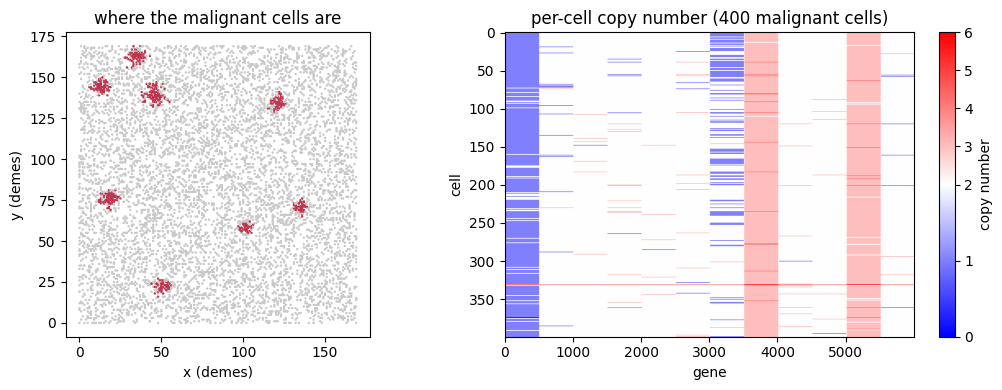

In [2]:
gid = cd["cell_type"]["cell_id"].astype(str).values
types = np.array([tumor.genotypes[g].type if g in tumor.genotypes else "?" for g in gid])
is_cancer = types == "cancer"
cnv = cd["cell_cnv"].values

print(f"cells: {len(types):,}   malignant {is_cancer.sum():,}   normal {(~is_cancer).sum():,} "
      f"(purity {is_cancer.mean():.1%})")
print(f"genome: {cnv.shape[1]:,} genes over {tumor.n_segments} segments")
print("\ncell types present:", ", ".join(f"{t} {int((types==t).sum()):,}"
                                          for t in sorted(set(types))))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
crd = cd["cell_crd"]
axes[0].scatter(crd["col"], crd["row"], c=np.where(is_cancer, "#c1344e", "#c9c9c9"),
                s=3, linewidths=0)
axes[0].set_title("where the malignant cells are"); axes[0].set_aspect("equal")
axes[0].set_xlabel("x (demes)"); axes[0].set_ylabel("y (demes)")

# Copy number is a DIVERGING quantity around the diploid baseline, so it gets a diverging map
# centred at 2 — and the scale never goes below zero, because negative copy number is not a thing.
from matplotlib.colors import TwoSlopeNorm
im = axes[1].imshow(cnv[is_cancer][:400], aspect="auto", cmap="bwr",
                    norm=TwoSlopeNorm(vcenter=2.0, vmin=0.0, vmax=max(4.0, cnv.max())))
axes[1].set_title("per-cell copy number (400 malignant cells)")
axes[1].set_xlabel("gene"); axes[1].set_ylabel("cell")
fig.colorbar(im, ax=axes[1], label="copy number")
fig.tight_layout()

## The datasets, and what each tool is allowed to see

`make_analysis_data.py` turns a tumour like the one above into plain tables. The split is the point:
the tool reads the left column, and the right column is opened only once the tool has committed to an
answer.

| dataset | what the tool reads | ground truth, held back |
|---|---|---|
| `clonealign` | scRNA counts (cells × genes), clone copy number (genes × clones) | each cell's true clone |
| `numbat` | expression counts, a normal reference, phased allele counts, gene annotation | malignant vs normal, and each cell's clone |
| `rctd` | a Visium section (counts + coordinates) and a paired scRNA reference | the true cell-type proportion of every spot |
| `treemhn` | SCITE-reconstructed mutation trees, and a noisy single-cell genotype matrix per patient | the planted precedence network, **and** iscc's own true trees |
| `mhn` | the same kind of cohort read cross-sectionally, plus a no-constraint control arm | the planted precedence network |
| `cohort` | pooled scRNA counts from five patients, with a batch label | the shared program dictionary and every cell's true program activities |

Each dataset also ships a `meta.json` recording the shape of the problem and the **baselines that
make a score readable** — chance, and the majority-class rate. A method that beats chance but not
the majority baseline has not done anything useful, and the number alone will not tell you that.

In [3]:
import json
DATA = os.path.join("..", "analysis_data")
if not os.path.isdir(DATA):
    print("datasets not generated yet — run:  python validation/make_analysis_data.py")
else:
    man = json.load(open(os.path.join(DATA, "manifest.json")))
    for name, m in man["datasets"].items():
        keep = {k: v for k, v in m.items()
                if k in ("n_cells", "n_genes", "n_clones", "n_spots", "n_patients",
                         "chance_baseline", "majority_baseline", "spot_purity_mean",
                         "frac_spots_multitype", "cells_per_spot_mean")}
        pretty = ", ".join(f"{k}={v:,}" if isinstance(v, int) else f"{k}={v:.2f}"
                           for k, v in keep.items())
        print(f"  {name:<12} {pretty}")

  rctd         n_spots=2,542, cells_per_spot_mean=4.89, spot_purity_mean=0.72, frac_spots_multitype=0.75
  clonealign   n_cells=1,501, n_genes=6,000, n_clones=4, majority_baseline=0.49, chance_baseline=0.25
  numbat       n_clones=4, n_cells=1,677, n_genes=6,000
  treemhn      n_patients=36
  cohort       n_patients=5, n_cells=1,500, n_genes=400
  mhn          n_patients=295


## The true clone phylogeny

The one piece of ground truth that no experiment recovers directly: **which clone descends from
which**. Every tree-inference method estimates this from mutations, and every published tree is a
hypothesis. Here it is recorded.

`iscc.inference.clone_tree` contracts the genotype genealogy onto the *clone* phylogeny — each node is
a block of genotypes sharing one driver combination, sized by how many cells it holds. This is the
answer the tree notebooks are scored against.

true clone phylogeny: 987 clones, 1 root(s)
  largest clones: [7764, 3497, 1145, 616, 597, 525]


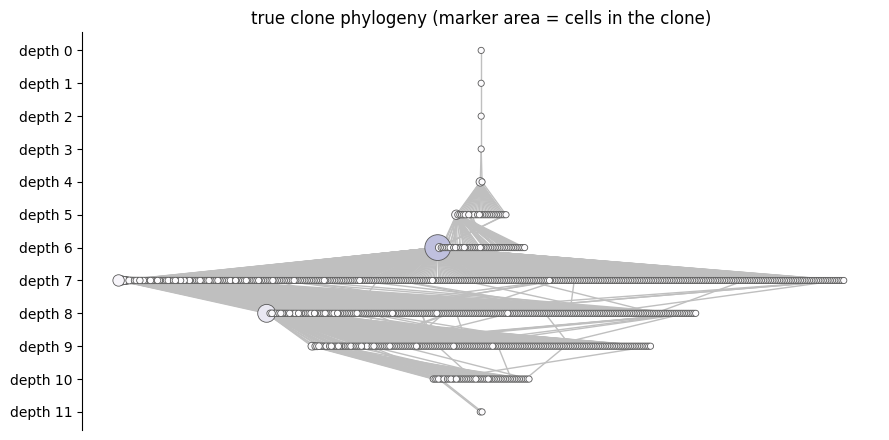

In [4]:
from iscc.inference import clone_tree

parents, sizes = clone_tree(tumor)
roots = [n for n in sizes if n not in parents]
print(f"true clone phylogeny: {len(sizes)} clones, {len(roots)} root(s)")
print(f"  largest clones: {sorted(sizes.values(), reverse=True)[:6]}")

# Draw it: depth from the root on y, clone size as the marker area.
depth = {}
def _depth(n):
    if n in depth: return depth[n]
    depth[n] = 0 if n not in parents else _depth(parents[n]) + 1
    return depth[n]
for n in sizes: _depth(n)

order = sorted(sizes, key=lambda n: (depth[n], -sizes[n]))
xpos = {}
by_depth = {}
for n in order:
    by_depth.setdefault(depth[n], []).append(n)
for d, ns in by_depth.items():
    for i, n in enumerate(ns):
        xpos[n] = i - (len(ns) - 1) / 2

fig, ax = plt.subplots(figsize=(9, 4.5))
for child, parent in parents.items():
    if parent in xpos and child in xpos:
        ax.plot([xpos[parent], xpos[child]], [-depth[parent], -depth[child]],
                color="0.75", lw=1, zorder=1)
tot = max(sum(sizes.values()), 1)
ax.scatter([xpos[n] for n in sizes], [-depth[n] for n in sizes],
           s=[20 + 900 * sizes[n] / tot for n in sizes],
           c=[sizes[n] / tot for n in sizes], cmap="Purples",   # fractions -> Purples
           vmin=0, vmax=1, edgecolors="0.35", linewidths=0.6, zorder=2)
ax.set_yticks(sorted({-d for d in depth.values()}))
ax.set_yticklabels([f"depth {abs(t)}" for t in sorted({-d for d in depth.values()})])
ax.set_xticks([]); ax.set_title("true clone phylogeny (marker area = cells in the clone)")
for sp in ("top", "right", "bottom"): ax.spines[sp].set_visible(False)
fig.tight_layout()

## The truth each tool is scored against

Everything below is loaded from the `truth_*` files of the actual datasets the analysis notebooks
read. **This is where the answer key is drawn.** Those notebooks show what their tool produced, using
the tool's own plotting; the panels to hold that output against are here, so the comparison is a
comparison of two figures rather than a figure the benchmark drew for you.

clonealign — true clone sizes: {0: 575, 1: 730, 2: 87, 3: 109}
            majority baseline 0.49, chance 0.25
numbat     — 1,527 malignant of 1,677 cells (purity 91.1%), 3 malignant clones


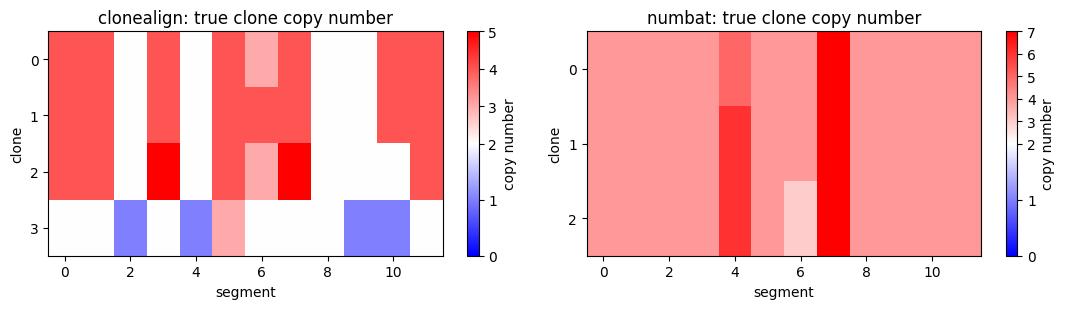

In [5]:
import numpy as np
DATA = os.path.join("..", "analysis_data")

# --- clonealign: which clone each cell really belongs to, and what copy number that clone carries
ca_truth = pd.read_csv(os.path.join(DATA, "clonealign", "truth.csv"))
ca_meta  = json.load(open(os.path.join(DATA, "clonealign", "meta.json")))
cn = np.array(ca_meta["cn_consensus"])

# --- numbat: which cells are malignant, and the consensus copy number of each malignant clone
nb_truth = pd.read_csv(os.path.join(DATA, "numbat", "truth.csv"))
nb_cn = np.loadtxt(os.path.join(DATA, "numbat", "truth_consensus_cn.csv"), delimiter=",", ndmin=2)

print("clonealign — true clone sizes:", ca_truth["true_clone"].value_counts().sort_index().to_dict())
print(f"            majority baseline {ca_meta['majority_baseline']:.2f}, chance {ca_meta['chance_baseline']:.2f}")
print(f"numbat     — {int(nb_truth['is_malignant'].sum()):,} malignant of {len(nb_truth):,} cells "
      f"(purity {nb_truth['is_malignant'].mean():.1%}), {nb_cn.shape[0]} malignant clones")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, M, title in ((axes[0], cn, "clonealign: true clone copy number"),
                     (axes[1], nb_cn, "numbat: true clone copy number")):
    im = ax.imshow(M, cmap="bwr", norm=TwoSlopeNorm(vcenter=2.0, vmin=0.0, vmax=max(4.0, M.max())),
                   aspect="auto")
    ax.set_xlabel("segment"); ax.set_ylabel("clone"); ax.set_title(title)
    ax.set_yticks(range(M.shape[0]))
    fig.colorbar(im, ax=ax, label="copy number")
fig.tight_layout()

### Spatial: what is actually in each Visium spot

`iscc` placed the cells, so it knows each spot's composition exactly — no reference-based estimate
standing in for truth. This is the panel to compare RCTD's weight maps against.

2,542 spots; mean composition: {'cancer': 0.21, 'epithelial': 0.004, 'stromal': 0.542, 'immune': 0.243}


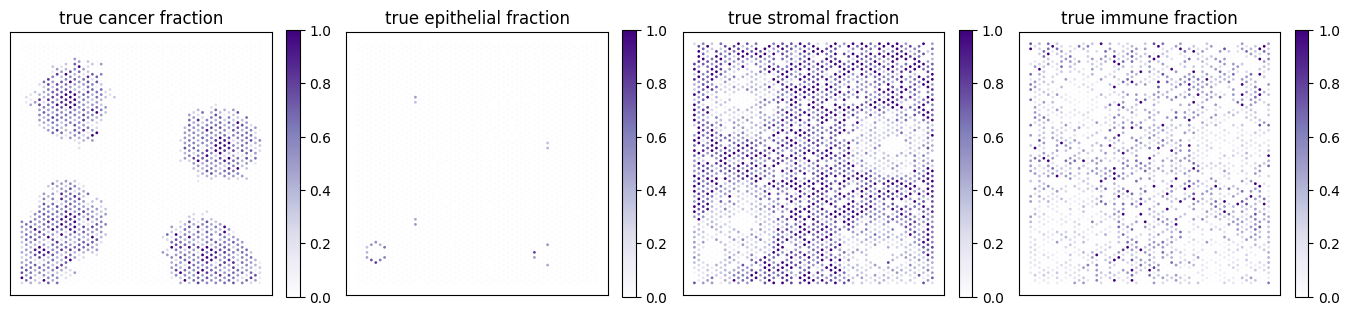

In [6]:
sp_truth  = pd.read_csv(os.path.join(DATA, "rctd", "truth_type_composition.csv"), index_col=0)
sp_coords = pd.read_csv(os.path.join(DATA, "rctd", "sp_coords.csv"), index_col=0)
types = [c for c in sp_truth.columns if sp_truth[c].sum() > 0]
print(f"{len(sp_truth):,} spots; mean composition:",
      {c: round(float(sp_truth[c].mean()), 3) for c in types})

fig, axes = plt.subplots(1, len(types), figsize=(3.4 * len(types), 3.4))
for ax, k in zip(np.atleast_1d(axes), types):
    s = ax.scatter(sp_coords["x"], sp_coords["y"], c=sp_truth.loc[sp_coords.index, k],
                   cmap="Purples", vmin=0, vmax=1, s=4, linewidths=0)   # fractions -> Purples
    ax.set_title(f"true {k} fraction"); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(s, ax=ax, fraction=0.046)
fig.tight_layout()

### The gene programs, and which genes are in them

The cohort dataset plants **one shared program dictionary** that every patient draws from, while each
patient's tumour evolves privately. Two things are recorded: the **loading matrix** (which genes each
program spans, and how strongly) and the **per-cell activities** (how much each cell used each
program). A method that claims to have recovered a program can be held against both.

6 programs over 400 genes; {'program0': 25, 'program1': 25, 'program2': 25, 'program3': 25, 'program4': 25, 'program5': 25} genes carried per program

  program0: G_2_7 2.23, G_6_38 2.08, G_9_34 1.48, G_9_13 1.25, G_2_13 1.12, G_3_30 0.98
  program1: G_7_39 2.40, G_3_35 2.19, G_5_35 1.90, G_6_5 1.80, G_8_29 1.62, G_8_9 1.52
  program2: G_0_23 2.09, G_8_35 1.70, G_1_13 1.54, G_7_24 1.36, G_7_14 1.20, G_3_13 1.17
  program3: G_7_21 3.39, G_3_16 2.07, G_8_35 2.03, G_8_7 1.61, G_2_13 1.01, G_3_33 0.85
  program4: G_4_18 3.21, G_6_9 2.01, G_6_35 1.66, G_0_26 1.66, G_6_7 1.33, G_1_19 1.00
  program5: G_5_8 6.08, G_1_25 4.74, G_0_22 4.48, G_2_4 3.70, G_9_0 2.64, G_0_30 2.16


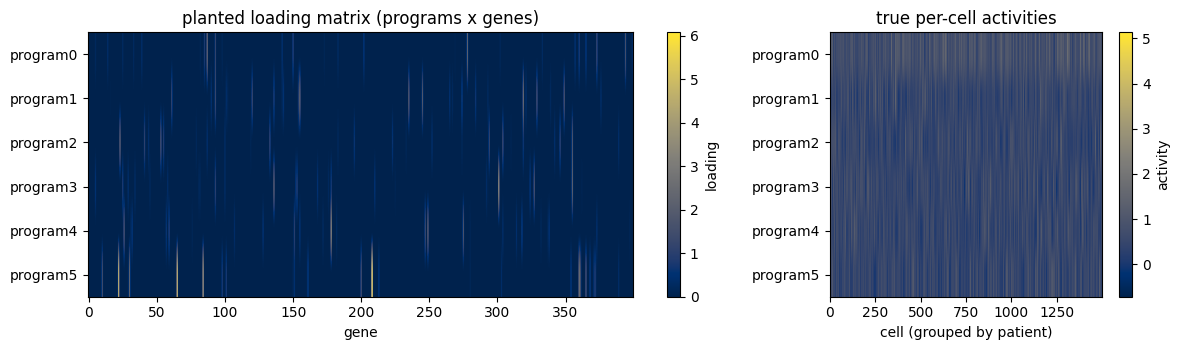

In [7]:
loading  = pd.read_csv(os.path.join(DATA, "cohort", "truth_loading.csv.gz"), index_col=0)
activity = pd.read_csv(os.path.join(DATA, "cohort", "truth_activity.csv.gz"), index_col=0)
obs      = pd.read_csv(os.path.join(DATA, "cohort", "obs.csv"), index_col=0)

print(f"{loading.shape[0]} programs over {loading.shape[1]} genes; "
      f"{(loading > 0).sum(1).to_dict()} genes carried per program\n")
for prog in loading.index:                       # the genes that DEFINE each program
    top = loading.loc[prog].sort_values(ascending=False).head(6)
    print(f"  {prog}: " + ", ".join(f"{g} {w:.2f}" for g, w in top.items()))

order = np.argsort(obs.loc[activity.index, "patient"].values, kind="stable")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), width_ratios=[2, 1])
im = axes[0].imshow(loading.values, aspect="auto", cmap="cividis")   # programs -> cividis
axes[0].set_yticks(range(loading.shape[0])); axes[0].set_yticklabels(loading.index)
axes[0].set_xlabel("gene"); axes[0].set_title("planted loading matrix (programs x genes)")
fig.colorbar(im, ax=axes[0], label="loading")

im = axes[1].imshow(activity.values[order].T, aspect="auto", cmap="cividis")
axes[1].set_yticks(range(activity.shape[1])); axes[1].set_yticklabels(activity.columns)
axes[1].set_xlabel("cell (grouped by patient)"); axes[1].set_title("true per-cell activities")
fig.colorbar(im, ax=axes[1], label="activity")
fig.tight_layout()

### Progression: the planted network, and the trees it produced

The progression cohort is grown under a **DAG** stating which events must precede which, gated on
*accessibility* so the constraint acts on the mutation process itself and therefore shows up in tree
topology. Two ground truths come out of it: the DAG, and each patient's true mutation tree.

The tree matters because the trees TreeMHN reads are **not** these — they are reconstructed by SCITE
from noisy single-cell genotypes, exactly as a real study would. These are what that reconstruction
is scored against.

planted precedence constraints (accessibility-gated):
   E3  must precede  E1
   E0  must precede  E2

event presence at min_freq=0: {'E0': 1.0, 'E1': 0.44, 'E2': 0.33, 'E3': 1.0}
median cancer-cell fraction:   {'E0': 0.07, 'E1': 0.0, 'E2': 0.0, 'E3': 0.134}

true mutation trees: 36 patients, 150 nodes total



MHN cohort: 295 patients (295 control), event_size 7, 150 growth steps
  presence: {'E0': 0.78, 'E1': 0.06, 'E2': 0.25, 'E3': 0.83}  control: {'E0': 0.8, 'E1': 0.63, 'E2': 0.94, 'E3': 0.64}


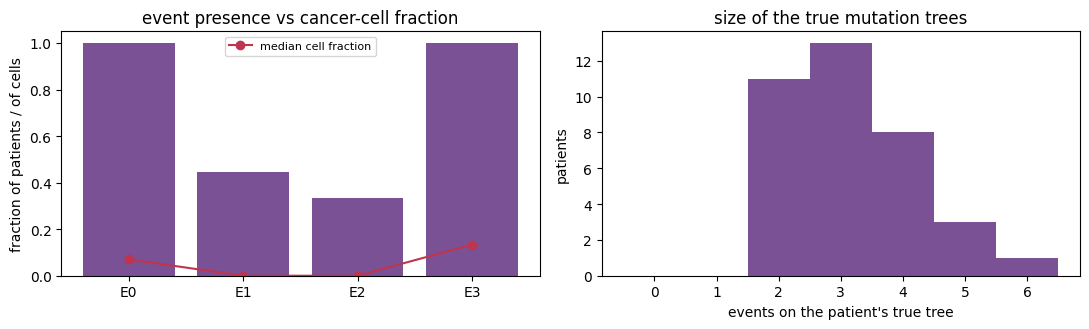

In [8]:
tm = os.path.join(DATA, "treemhn")
truth_net = json.load(open(os.path.join(tm, "truth_network.json")))
dag = truth_net["true_dag_edges"]
X   = pd.read_csv(os.path.join(tm, "X_presence.csv"), index_col=0)
F   = pd.read_csv(os.path.join(tm, "X_cellfraction.csv"), index_col=0)
ev  = list(X.columns)

print(f"planted precedence constraints ({truth_net['dependency_params']['gating_mode']}-gated):")
for p, c in dag:
    print(f"   {ev[p]}  must precede  {ev[c]}")

# The binary column is at min_freq=0 -- ANY cell carrying the event counts. The continuous
# cancer-cell-fraction matrix is the same cohort without that floor collapsed in.
print("\nevent presence at min_freq=0:", X.mean(0).round(2).to_dict())
print("median cancer-cell fraction:  ", F.median(0).round(3).to_dict())

truth_trees = pd.read_csv(os.path.join(tm, "truth_trees.csv"))
print(f"\ntrue mutation trees: {truth_trees['Patient_ID'].nunique()} patients, "
      f"{len(truth_trees)} nodes total")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(ev, X.mean(0).values, color="#7a5195")
axes[0].plot(ev, F.median(0).values, "o-", color="#c1344e", label="median cell fraction")
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("fraction of patients / of cells")
axes[0].set_title("event presence vs cancer-cell fraction"); axes[0].legend(fontsize=8)

sizes = truth_trees.groupby("Patient_ID").size() - 1        # nodes below the root = events acquired
axes[1].hist(sizes, bins=range(0, int(sizes.max()) + 2), color="#7a5195", align="left")
axes[1].set_xlabel("events on the patient's true tree"); axes[1].set_ylabel("patients")
axes[1].set_title("size of the true mutation trees")
fig.tight_layout()

# The SAME kind of constraint, in the cohort built for the cross-sectional view. It is a separate
# cohort because the two observables need different densities: the trees above need events common
# enough to leave an ordering trace, which fixes the parents in every patient and leaves a
# presence/absence method nothing to estimate.
mhn_dir = os.path.join(DATA, "mhn")
if os.path.isdir(mhn_dir):
    Xm  = pd.read_csv(os.path.join(mhn_dir, "X_presence.csv"), index_col=0)
    Xc  = pd.read_csv(os.path.join(mhn_dir, "X_presence_control.csv"), index_col=0)
    mm  = json.load(open(os.path.join(mhn_dir, "meta.json")))
    print(f"\nMHN cohort: {mm['n_patients']} patients ({mm['n_control_patients']} control), "
          f"event_size {mm['event_size']}, {mm['grow_steps']} growth steps")
    print("  presence:", Xm.mean(axis=0).round(2).to_dict(),
          " control:", Xc.mean(axis=0).round(2).to_dict())


## Reading a score honestly

Two habits carried through every notebook in this section, both learned from results that looked
fine and were not:

**Report the baseline, not just the score.** A clone-assignment accuracy of 0.67 sounds reasonable
until you notice the largest clone holds 70% of the cells. Every scoring cell prints chance and
majority beside the result.

**Report a threshold-free measure too.** Accuracy depends on where a cut-off falls and on how
imbalanced the classes are; AUC and ARI do not. A method can rank cells correctly — real, usable
signal — and still lose on hard assignment. Reporting only the first number would call that a
failure.